# Black Friday - Regresión con Keras
Notebook base para la entrega (preprocesamiento + modelo + TensorBoard).

In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
def find_dataset_path():
    candidates = [
        Path('blkfri_train.csv'),
        Path('SAA/blkfri_train.csv'),
        Path('../SAA/blkfri_train.csv'),
        Path('../../SAA/blkfri_train.csv')
    ]
    for path in candidates:
        if path.exists():
            return path

    for root in [Path('.'), Path('..')]:
        matches = list(root.rglob('blkfri_train.csv'))
        if matches:
            return matches[0]

    raise FileNotFoundError('No se encontro blkfri_train.csv. Ajusta find_dataset_path().')

data_path = find_dataset_path()
df = pd.read_csv(data_path)
print('Dataset:', data_path)
print(df.shape)
df.head()

Dataset: blkfri_train.csv
(550068, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
target_col = 'Purchase'
drop_cols = ['User_ID', 'Product_ID']

features_df = df.drop(columns=drop_cols + [target_col]).copy()
target = df[target_col].astype(np.float32).values

categorical_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
categorical_cols = [c for c in categorical_cols if c in features_df.columns]
numeric_cols = [c for c in features_df.columns if c not in categorical_cols]

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    features_df, target, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

X_train_t = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else X_train_t
X_val_t = X_val_t.toarray() if hasattr(X_val_t, 'toarray') else X_val_t
X_test_t = X_test_t.toarray() if hasattr(X_test_t, 'toarray') else X_test_t

print('Train:', X_train_t.shape, 'Val:', X_val_t.shape, 'Test:', X_test_t.shape)

Train: (352043, 22) Val: (88011, 22) Test: (110014, 22)


In [4]:
def build_model(input_dim, activation='relu', use_batchnorm=False, dropout=0.2, optimizer='adam', lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in [128, 96, 64]:
        model.add(layers.Dense(units))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1))

    opt_name = optimizer.lower()
    if opt_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

In [5]:
base_config = {
    'name': 'keras_base',
    'activation': 'relu',
    'batchnorm': False,
    'optimizer': 'adam',
    'lr': 1e-3,
    'dropout': 0.2,
    'epochs': 80,
    'batch_size': 1024
}

model = build_model(
    input_dim=X_train_t.shape[1],
    activation=base_config['activation'],
    use_batchnorm=base_config['batchnorm'],
    dropout=base_config['dropout'],
    optimizer=base_config['optimizer'],
    lr=base_config['lr']
)

tb_root = Path.cwd() / 'logs' / 'fit'
tb_root.mkdir(parents=True, exist_ok=True)
log_dir = tb_root / f"{base_config['name']}_{int(time.time())}"
log_dir.mkdir(parents=True, exist_ok=True)

# TensorBoard y early stopping para registrar metricas e histogramas
tb_cb = keras.callbacks.TensorBoard(log_dir=str(log_dir), histogram_freq=1)
es_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=base_config['epochs'],
    batch_size=base_config['batch_size'],
    callbacks=[tb_cb, es_cb],
    verbose=1
)

preds = model.predict(X_test_t).ravel()
metrics = evaluate_model(y_test, preds)
print('TensorBoard log:', log_dir)
print(metrics)

Epoch 1/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 49801056.0000 - mae: 5408.2178 - val_loss: 21663930.0000 - val_mae: 3525.1589
Epoch 2/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 21804142.0000 - mae: 3563.0266 - val_loss: 20139860.0000 - val_mae: 3384.8623
Epoch 3/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20344994.0000 - mae: 3393.2734 - val_loss: 18939320.0000 - val_mae: 3239.9685
Epoch 4/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19636310.0000 - mae: 3289.0630 - val_loss: 18474466.0000 - val_mae: 3174.9780
Epoch 5/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19332602.0000 - mae: 3247.6506 - val_loss: 18216922.0000 - val_mae: 3137.2449
Epoch 6/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19105924.0000 - mae: 3219.8193 - val_loss: 18057270.0000 - val_mae: 3112.8245
Epoch 7/80
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19013368.0000 - mae: 3207.3442 - val_loss: 17957854.0000 - val_mae: 3098.3728
Epoch 8/80
344/344 ━━━━━━━━━━━━━━━

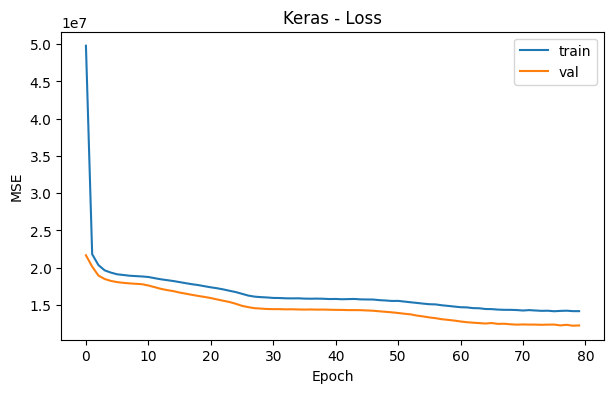

In [6]:
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Keras - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [8]:
experiment_configs = [
    {**base_config, 'name': 'keras_bn', 'batchnorm': True},
    {**base_config, 'name': 'keras_elu', 'activation': 'elu'},
    {**base_config, 'name': 'keras_sgd', 'optimizer': 'sgd', 'lr': 5e-3}
]

results = []
tb_root = Path.cwd() / 'logs' / 'fit'
tb_root.mkdir(parents=True, exist_ok=True)

for cfg in experiment_configs:
    m = build_model(
        input_dim=X_train_t.shape[1],
        activation=cfg['activation'],
        use_batchnorm=cfg['batchnorm'],
        dropout=cfg['dropout'],
        optimizer=cfg['optimizer'],
        lr=cfg['lr']
    )

    lg = tb_root / f"{cfg['name']}_{int(time.time())}"
    lg.mkdir(parents=True, exist_ok=True)
    tb = keras.callbacks.TensorBoard(log_dir=str(lg), histogram_freq=1)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    m.fit(
        X_train_t, y_train,
        validation_data=(X_val_t, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=[tb, es],
        verbose=0
    )

    p = m.predict(X_test_t, verbose=0).ravel()
    if np.isnan(p).any() or np.isinf(p).any():
        results.append({
            **cfg,
            'MSE': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'R2': np.nan,
            'log_dir': str(lg),
            'status': 'diverged'
        })
        continue

    met = evaluate_model(y_test, p)
    results.append({**cfg, **met, 'log_dir': str(lg), 'status': 'ok'})

pd.DataFrame(results)[['name', 'optimizer', 'activation', 'batchnorm', 'lr', 'MSE', 'RMSE', 'MAE', 'R2', 'status', 'log_dir']]

,name,optimizer,activation,batchnorm,lr,MSE,RMSE,MAE,R2,status,log_dir
0,keras_bn,adam,relu,True,0.001,9150950.0,3025.053719,2302.010742,0.635800,ok,c:\Users\usuario\Documents\BigData\Programacio...
1,keras_elu,adam,elu,False,0.001,12191245.0,3491.596340,2543.662354,0.514799,ok,c:\Users\usuario\Documents\BigData\Programacio...
2,keras_sgd,sgd,relu,False,0.005,NaN,NaN,NaN,NaN,diverged,c:\Users\usuario\Documents\BigData\Programacio...


### TensorBoard
Ejecuta en terminal:
`tensorboard --logdir=logs/fit`